# Figure 1: Structure functions from SWOT altimetry

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
import pyturbo_sf as psf
import pyproj
import numpy as np
linewidth = 2
fontsize = 12
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['savefig.dpi'] = 150
plt.rc('font', family='serif')
import gc

# Load SWOT Dataset

In [2]:
ds = xr.open_dataset('../../docs/source/examples/example_data/subset_swot.nc')
ds

<xarray.Dataset> Size: 2MB
Dimensions:  (y: 531, x: 69)
Coordinates:
    y        (y, x) float64 293kB ...
    x        (y, x) float64 293kB ...
Data variables:
    u        (y, x) float64 293kB ...
    v        (y, x) float64 293kB ...
    adv_u    (y, x) float64 293kB ...
    adv_v    (y, x) float64 293kB ...

# Compute third order Isotropic Longitudinal SF

In [3]:
%%time

bin_r = np.logspace(np.log10(2000.), np.log10(1.0e6), 11)

bins = {
    'r': bin_r,
}
iso_sf_lon = psf.get_isotropic_sf_2d(
    ds=ds,
    variables_names=["u","v"],
    order=3,
    bins=bins,
    fun='longitudinal',
    bootsize={'y':132,'x':69},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=0.1,
    window_size_r=8,
    window_size_theta=10,
    backend='loky',
    seed=42
)

Dimensions ('y', 'x') are already in the expected order
Dimension x has bootsize equal to or larger than dimension size. No bootstrapping will be done across this dimension.
Using bootsize: {'y': 132, 'x': 69}
Bootstrappable dimensions: ['y']
Single bootstrappable dimension (y). Using spacings: [1, 2, 4]

STARTING ISOTROPIC_SF WITH FUNCTION TYPE: longitudinal
Variables: ['u', 'v'], Order: 3
Confidence level: 0.95


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 20 bootstraps
Processing spacing 2 with 20 bootstraps
Processing spacing 4 with 20 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 658406788
Bins with points: 10/10
Marked 10 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP
All bins have converged or reached max bootstraps!

FINAL CONVERGENCE STATISTICS:
  Total bins with data (>10 points): 10
  Converged bins: 10
  Unconverged bins: 0
  Bins at max bootstraps: 0

Creating output dataset...
ISOTROPIC SF COMPLETED SUCCESSFULLY!
CPU times: use

# Compute advective SF

In [4]:
%%time
bin_r = np.logspace(np.log10(2000.), np.log10(1.0e6), 11)

bins = {
    'r': bin_r,
}
iso_sf_adv = psf.get_isotropic_sf_2d(
    ds=ds,
    variables_names=["u","v","adv_u","adv_v"],
    order=1,
    bins=bins,
    fun='advective',
    bootsize={'y':132,'x':69},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=1.0e-7,
    window_size_r=8,
    window_size_theta=10,
    backend='loky',
    seed=42
)

Dimensions ('y', 'x') are already in the expected order
Dimension x has bootsize equal to or larger than dimension size. No bootstrapping will be done across this dimension.
Using bootsize: {'y': 132, 'x': 69}
Bootstrappable dimensions: ['y']
Single bootstrappable dimension (y). Using spacings: [1, 2, 4]

STARTING ISOTROPIC_SF WITH FUNCTION TYPE: advective
Variables: ['u', 'v', 'adv_u', 'adv_v'], Order: 1
Confidence level: 0.95


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 20 bootstraps
Processing spacing 2 with 20 bootstraps
Processing spacing 4 with 20 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 538199070
Bins with points: 10/10
Marked 9 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP

Iteration 1 - 1 unconverged bins
Grouped unconverged bins into 1 groups

Processing 1 bins with step size 40 in density quartile 0
  Bin 9 CONVERGED with std 0.000000
All bins have converged or reached max bootstraps!

FINAL CONVERGENCE STATISTICS:
  Total 

# Plot Figure 1

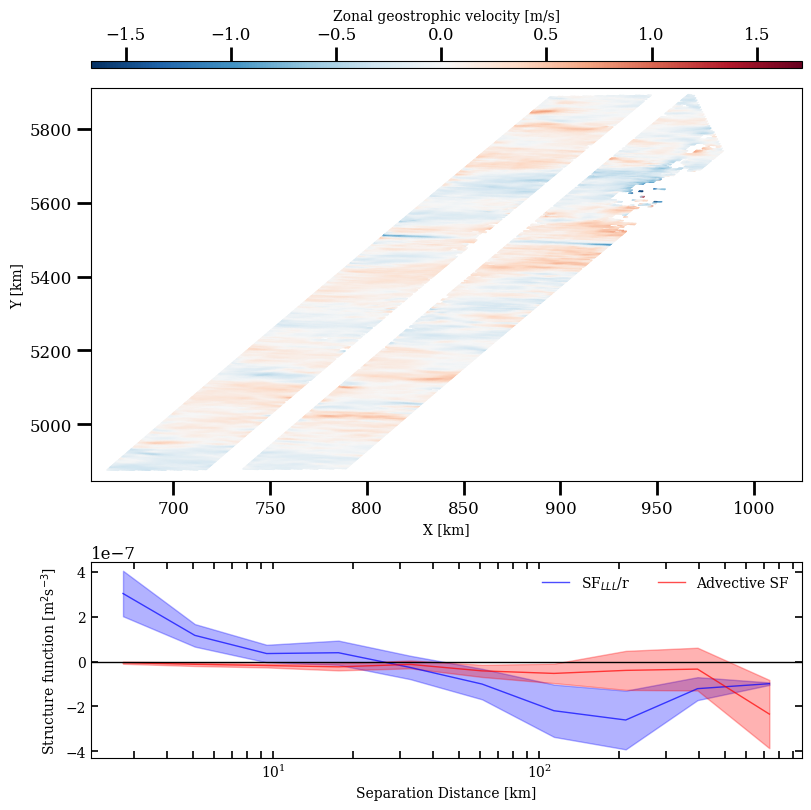

In [5]:
fig = plt.figure(layout="constrained", figsize=(8,8))

gs = GridSpec(3, 1, figure=fig,width_ratios=[0.5])
# gs.update(hspace=0.1)
ax1 = fig.add_subplot(gs[0:2, 0])
ax2 = fig.add_subplot(gs[2:, 0])

pc = ax1.pcolormesh(ds.x/1e3,ds.y/1e3,ds.u,cmap='RdBu_r',shading='gouraud')
fig.colorbar(
    pc,
    ax=ax1,
    location="top",
    aspect=100,
    label="Zonal geostrophic velocity [m/s]",
)
ax2.semilogx(iso_sf_lon.r.values/1e3,iso_sf_lon.sf.values/iso_sf_lon.r.values,color='b',linewidth=1,alpha=0.7,label="SF$_{LLL}$/r")
ax2.semilogx(iso_sf_adv.r.values/1e3,iso_sf_adv.sf.values,color='r',linewidth=1,alpha=0.7,label="Advective SF")
ax2.fill_between(iso_sf_lon.r.values/1e3, 
                iso_sf_lon.ci_lower.values/iso_sf_lon.r.values, 
                iso_sf_lon.ci_upper.values/iso_sf_lon.r.values, 
                alpha=0.3, color='blue')

ax2.fill_between(iso_sf_adv.r.values/1e3, 
                iso_sf_adv.ci_lower.values, 
                iso_sf_adv.ci_upper.values, 
                alpha=0.3, color='red')




ax2.hlines(0, 1e0, 1e3, lw=1, color="black")
ax2.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax2.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

ax1.set_xlabel("X [km]")
ax1.set_ylabel("Y [km]")

ax2.set_xlabel("Separation Distance [km]")
ax2.set_ylabel("Structure function [m$^2$s$^{-3}$]")
ax2.legend(loc="upper right", ncol=2, frameon=False)

plt.savefig('../figs/fig1.png',dpi=300,bbox_inches='tight')
